Text(0, 0.5, 'CNV Proportion')

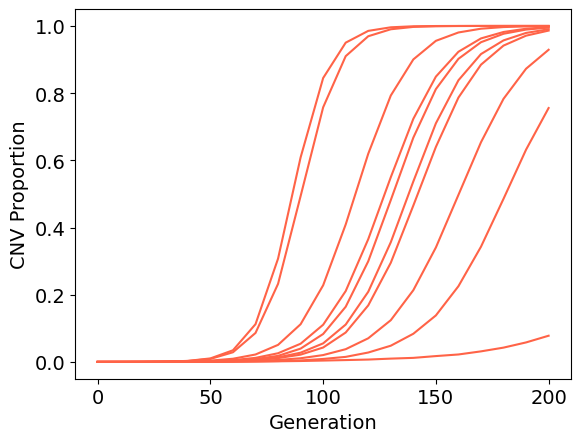

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot, kdeplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import CLASSIC_WF, CLASSIC_WF_wrapper, wrapper_hierarchical, wrapper
from inference_utils import get_prior
import warnings
warnings.simplefilter('ignore', FutureWarning)


# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

th = torch.tensor([-1.1,-5.5,6], dtype=torch.float32)
generation = torch.arange(0,201,10)
X = wrapper_hierarchical(CLASSIC_WF, parameters=th, reps=10, var = 0.2)
# th_out = prior.sample((1,))[0]
# X_out = wrapper_hierarchical(CLASSIC_WF, parameters=th_out, reps=2)
# X = torch.cat([X, X_out], dim=0)

change_font(14)

for i in range(len(X)):
    plt.plot(generation,X[i], color='tomato')
    # plt.plot(generation,X_emp[i], color='grey', label='empirical' if i==0 else '')
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')


In [123]:
prior = get_prior('CLASSIC_WF')
posterior_chuong = pickle.load(open('posterior_CLASSIC_WF_500000_20.pkl', 'rb'))
epsilon = -5

Xs = torch.tensor(X)
op = CollectivePosterior(prior, Xs, posterior_chuong,epsilon=epsilon)
op.get_log_C()

est = op.mcmc_from_top_sn(500, take_sn=20)
print(est.mean(0))

/tmp/ipykernel_404740/1685700011.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xs = torch.tensor(X)
MCMC from top SN: 100%|██████████| 500/500 [00:05<00:00, 91.52it/s]

tensor([-1.1043, -5.4252,  5.5821])


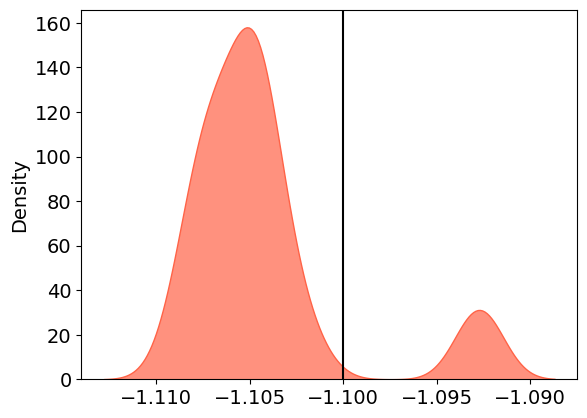

In [128]:
from seaborn import histplot, kdeplot
k = 0
kdeplot(est[:,k], color='tomato', alpha=0.7, fill=True)
plt.axvline(th[k], color='k')
# plt.xlim(prior.base_dist.low[0], prior.base_dist.high[0])
# plt.xlabel(r'$\log_{10}(\delta)$')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


tensor([[0.1532, 0.2016, 0.1129],
        [0.3306, 0.3306, 0.1371],
        [0.5161, 0.4597, 0.1855],
        [0.6048, 0.5968, 0.2984],
        [0.6855, 0.6371, 0.3952],
        [0.7339, 0.7258, 0.4919],
        [0.8226, 0.7661, 0.5887],
        [0.9113, 0.8306, 0.6694],
        [0.9435, 0.8790, 0.7823],
        [0.9597, 0.9032, 0.8145]])
tensor([[0.0806, 0.1048, 0.0726],
        [0.2177, 0.2258, 0.1290],
        [0.2903, 0.3387, 0.2419],
        [0.4516, 0.4919, 0.3468],
        [0.5645, 0.5726, 0.4435],
        [0.6694, 0.6371, 0.5806],
        [0.7661, 0.7339, 0.6694],
        [0.8629, 0.7742, 0.7258],
        [0.9516, 0.9194, 0.8145],
        [1.0000, 0.9597, 0.9032]])


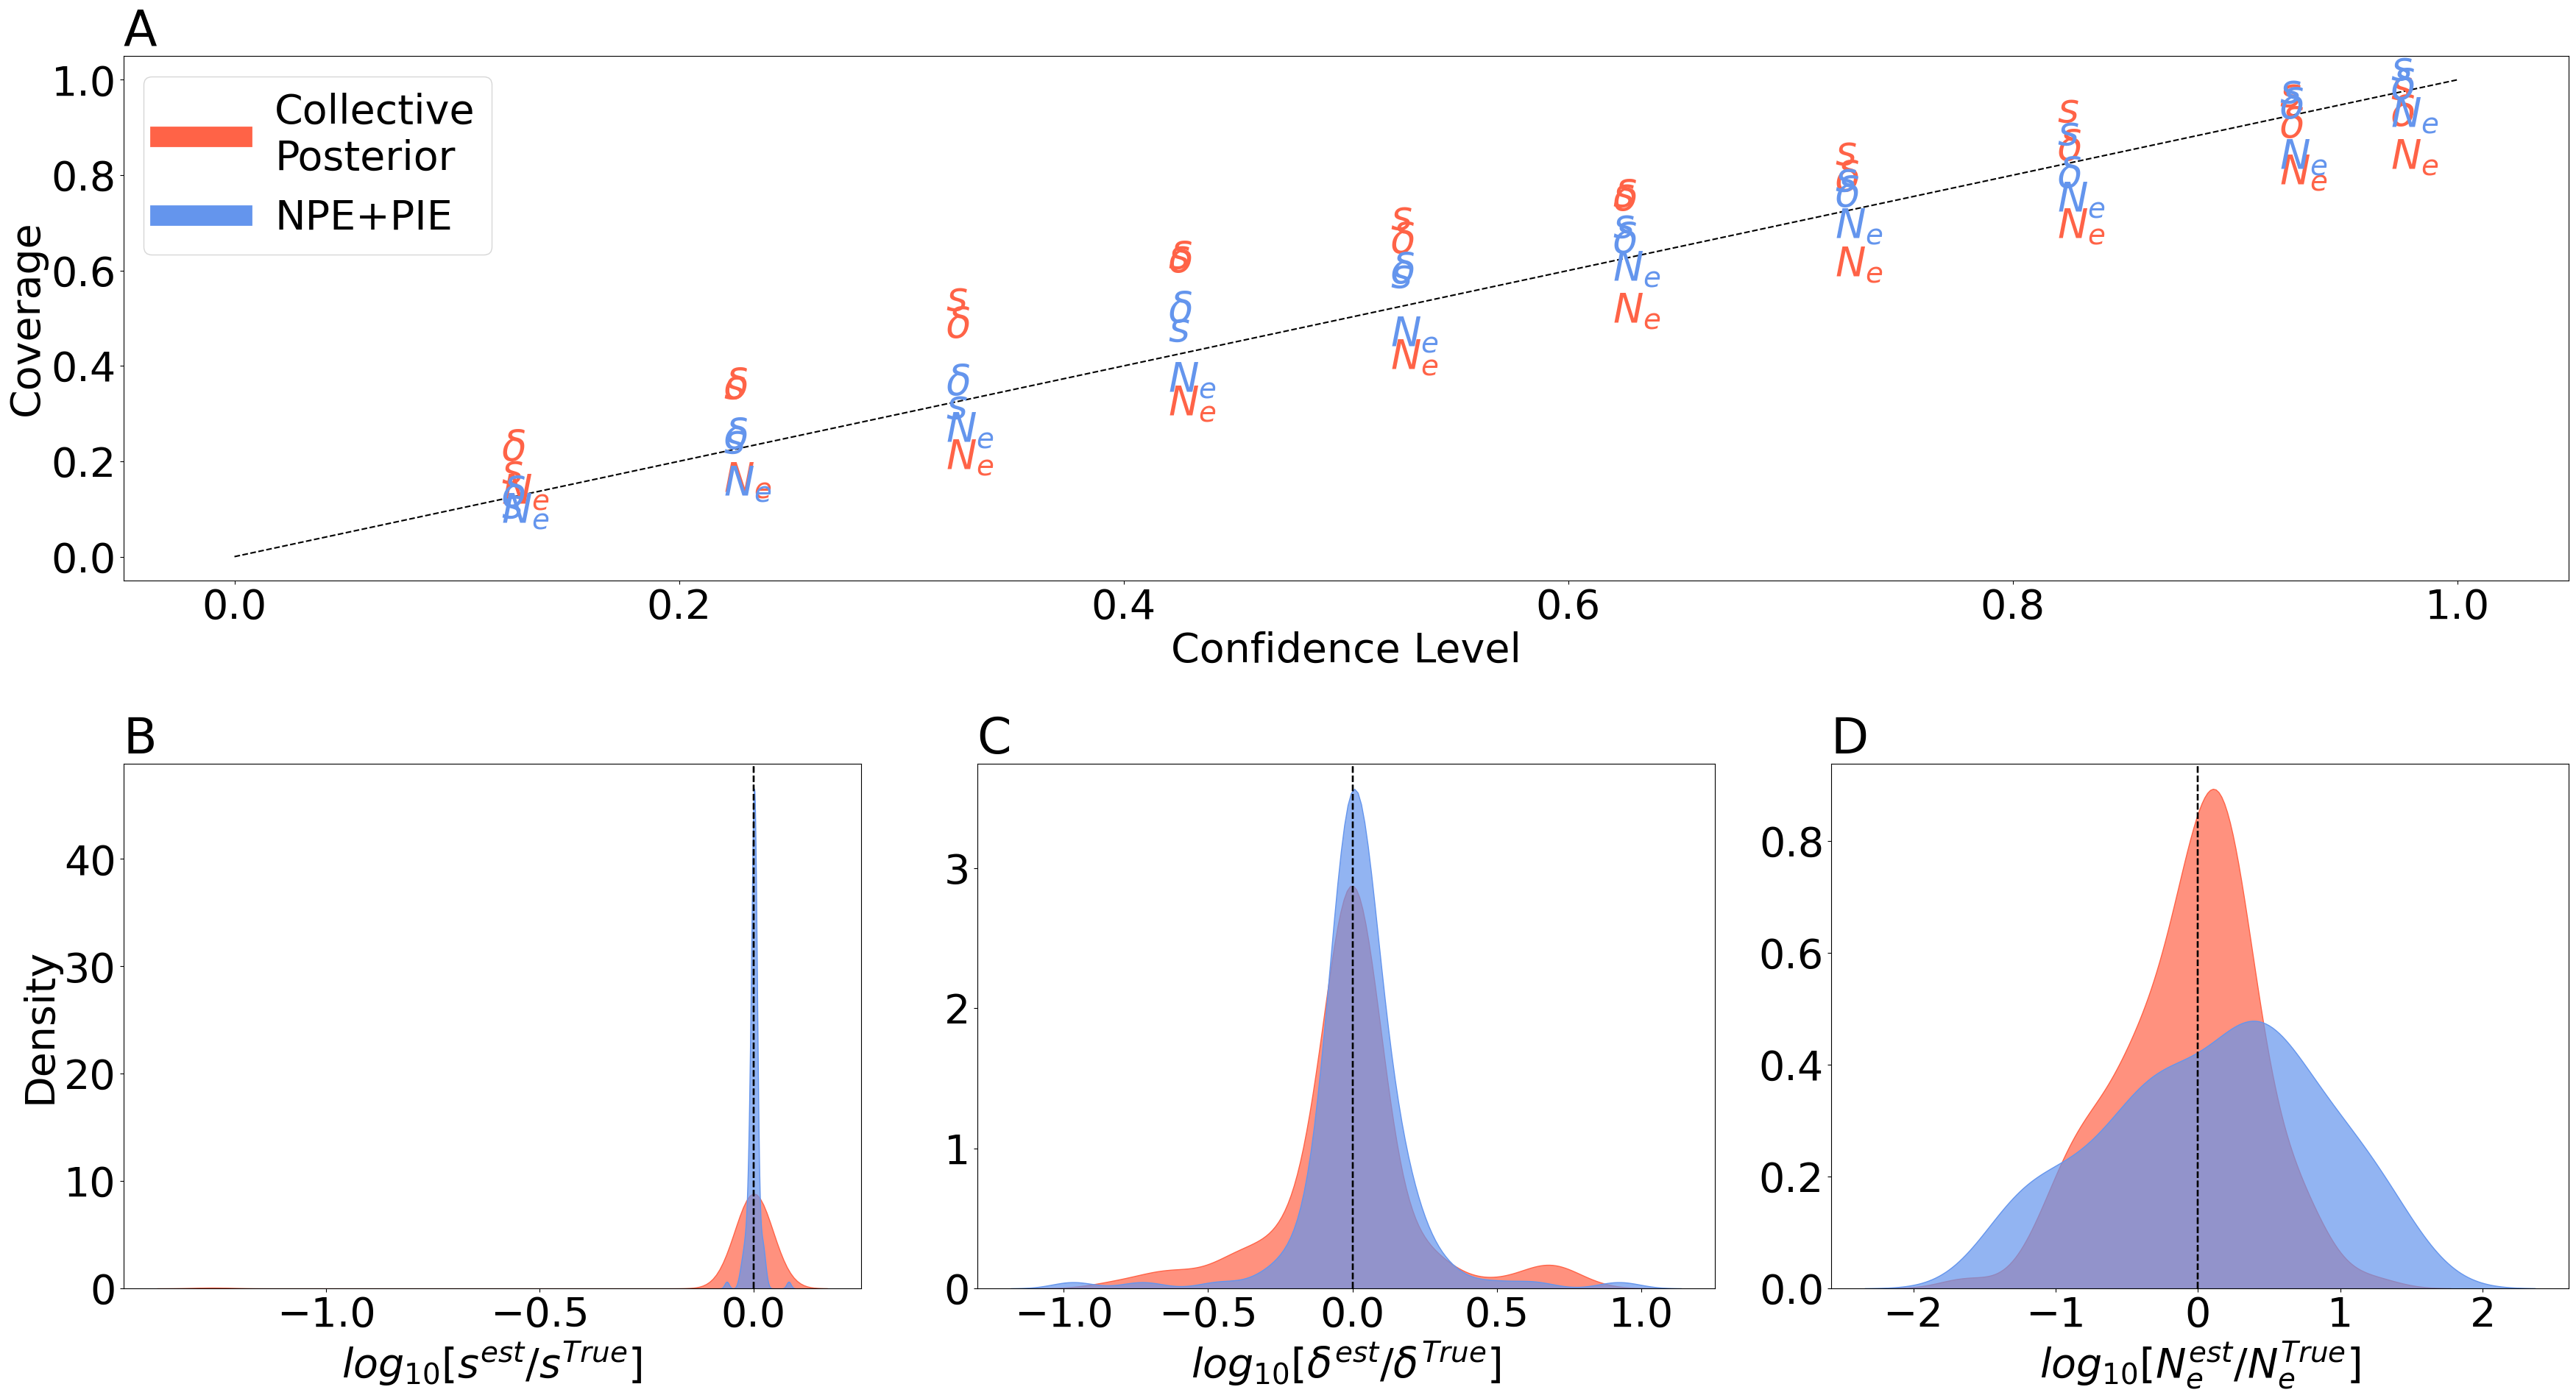

In [129]:
change_font(40)

def plot_accuracy(accs, ax, color, label, hatch):
    for i in range(len(ax)):
        kdeplot(accs[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
    return


def plot_covs(ax, covs, color, label, cp=True):
    conf_levels = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95]
    param_names = ['$s$', '$\\delta$', '$N_e$']
    adjust=0.02 if cp else 0
    covs = covs.mean(dim=0)
    print(covs)
    for i in range(len(param_names)):
        p = covs[:,i]
        word = param_names[i]
        for j in range(len(conf_levels)):
            ax.text(conf_levels[j]+adjust, p[j], word, color=color)
            # ax.scatter(covs.index[j]+adjust, covs[p].values[j], color=color, s=400)
    # ax.scatter(0,0,s=250, label=label, color=color)


# A - Coverage plots
# B-D - Accuracy plots
mosaic = '''AAA
            BCD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')


# Coverage plots in ax B
ax['A'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = torch.load(f'tests/covs_CLASSIC_WF_500k.pt')
plot_covs(ax=ax['A'], covs=covs_,label='Collective\nPosterior',color='tomato', cp=True)
covs_iid = torch.load(f'tests/covs_CLASSIC_WF_iid.pt')
plot_covs(ax=ax['A'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue')
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)

# Accuracy plots in ax C-E
n_params=3
ax['B'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['C'].set_xlabel('$log_{10}[\\delta^{est} / {\\delta^{True}}]$')
ax['D'].set_xlabel('$log_{10}[N_e^{est} / {N_e^{True}}]$')

axx = [ax['B'], ax['C'], ax['D']]

cp_acc = torch.load('tests/accus_CLASSIC_WF_50k.pt')
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = torch.load('tests/accus_CLASSIC_WF_iid.pt')
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['C'].set_ylabel('')
ax['D'].set_ylabel('')

# manual legend for ax[A]
handles = [plt.Line2D([0], [0], color='tomato', lw=20, label='Collective\nPosterior'),
           plt.Line2D([0], [0], color='cornflowerblue', lw=20, label='NPE+PIE')]
ax['A'].legend(handles=handles, fontsize=40, loc='upper left')

Text(0, 0.5, '')

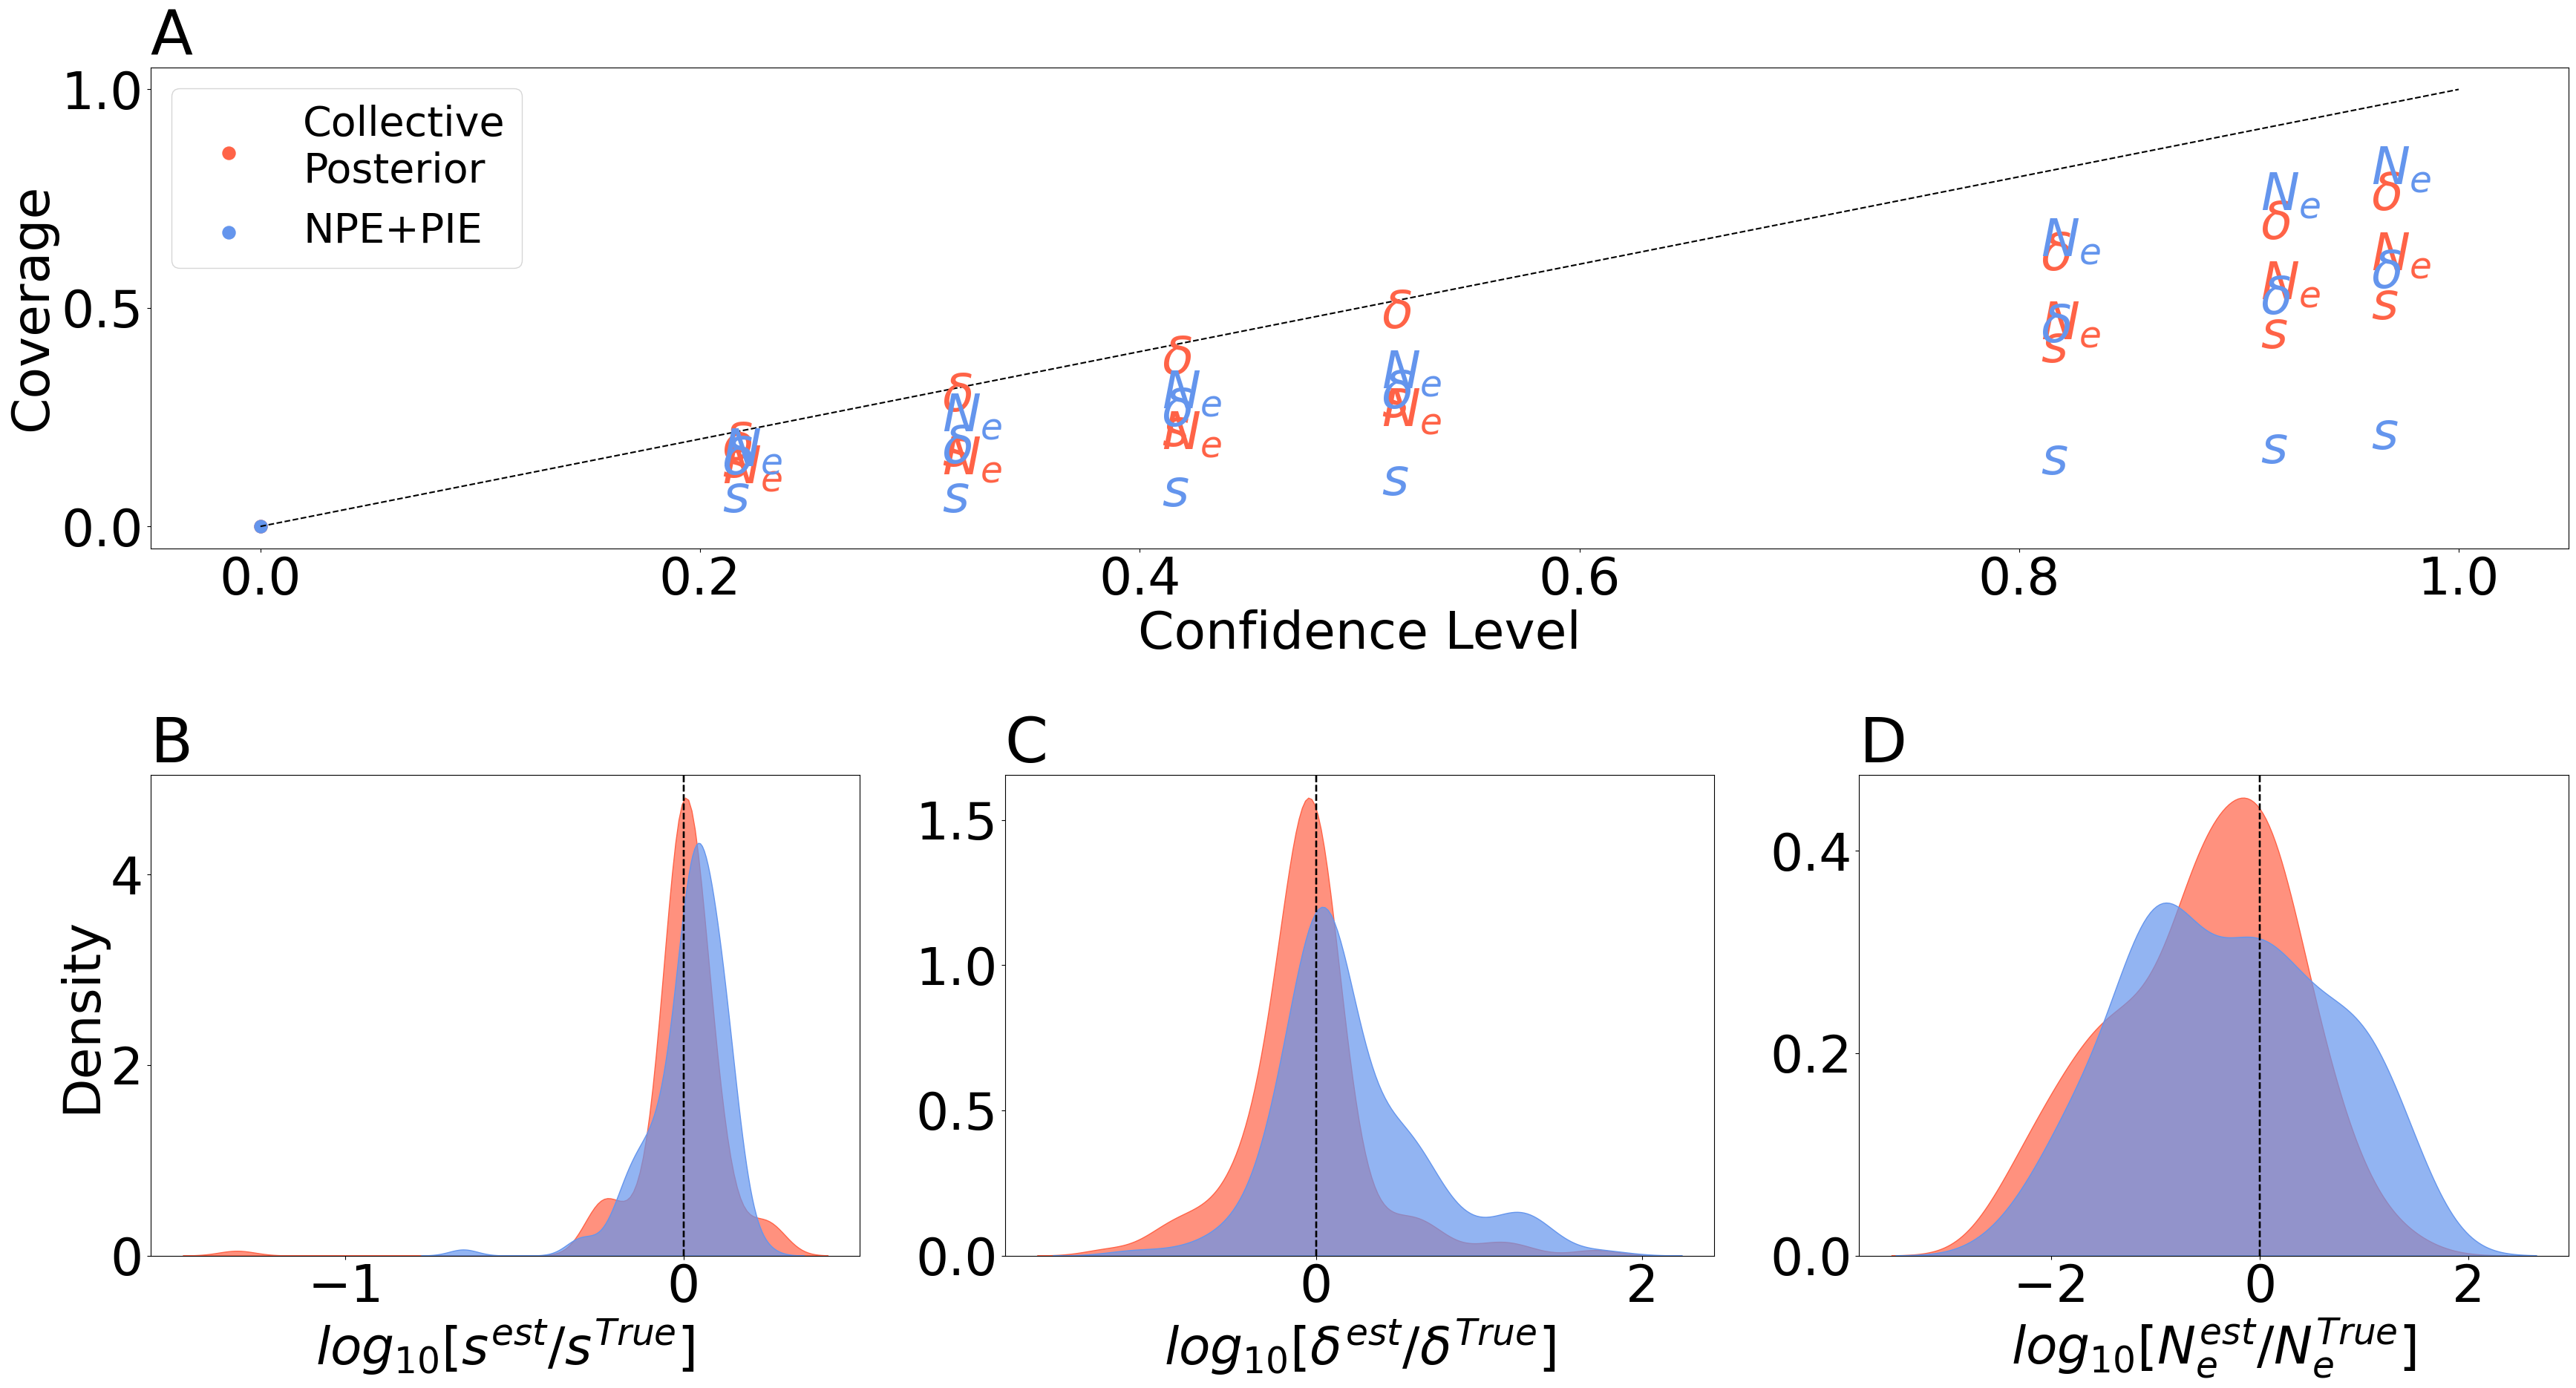

In [22]:
# A - Coverage plots
# B-D - Accuracy plots
mosaic = '''AAA
            BCD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')


# Coverage plots in ax B
ax['A'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = pd.read_csv(f'tests/covs_old_CLASSIC_WF_h_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['A'], covs=covs_,label='Collective\nPosterior',color='tomato', cp=True)
covs_iid = pd.read_csv(f'tests/covs_old_CLASSIC_WF_iid_h_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['A'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue')
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)

# Accuracy plots in ax C-E
n_params=3
ax['B'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['C'].set_xlabel('$log_{10}[\\delta^{est} / {\\delta^{True}}]$')
ax['D'].set_xlabel('$log_{10}[N_e^{est} / {N_e^{True}}]$')

axx = [ax['B'], ax['C'], ax['D']]

cp_acc = 'tests/accus_CLASSIC_WF_h_r.csv'
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = 'tests/accus_CLASSIC_WF_iid_h_r.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['C'].set_ylabel('')
ax['D'].set_ylabel('')


Text(0, 0.5, '')

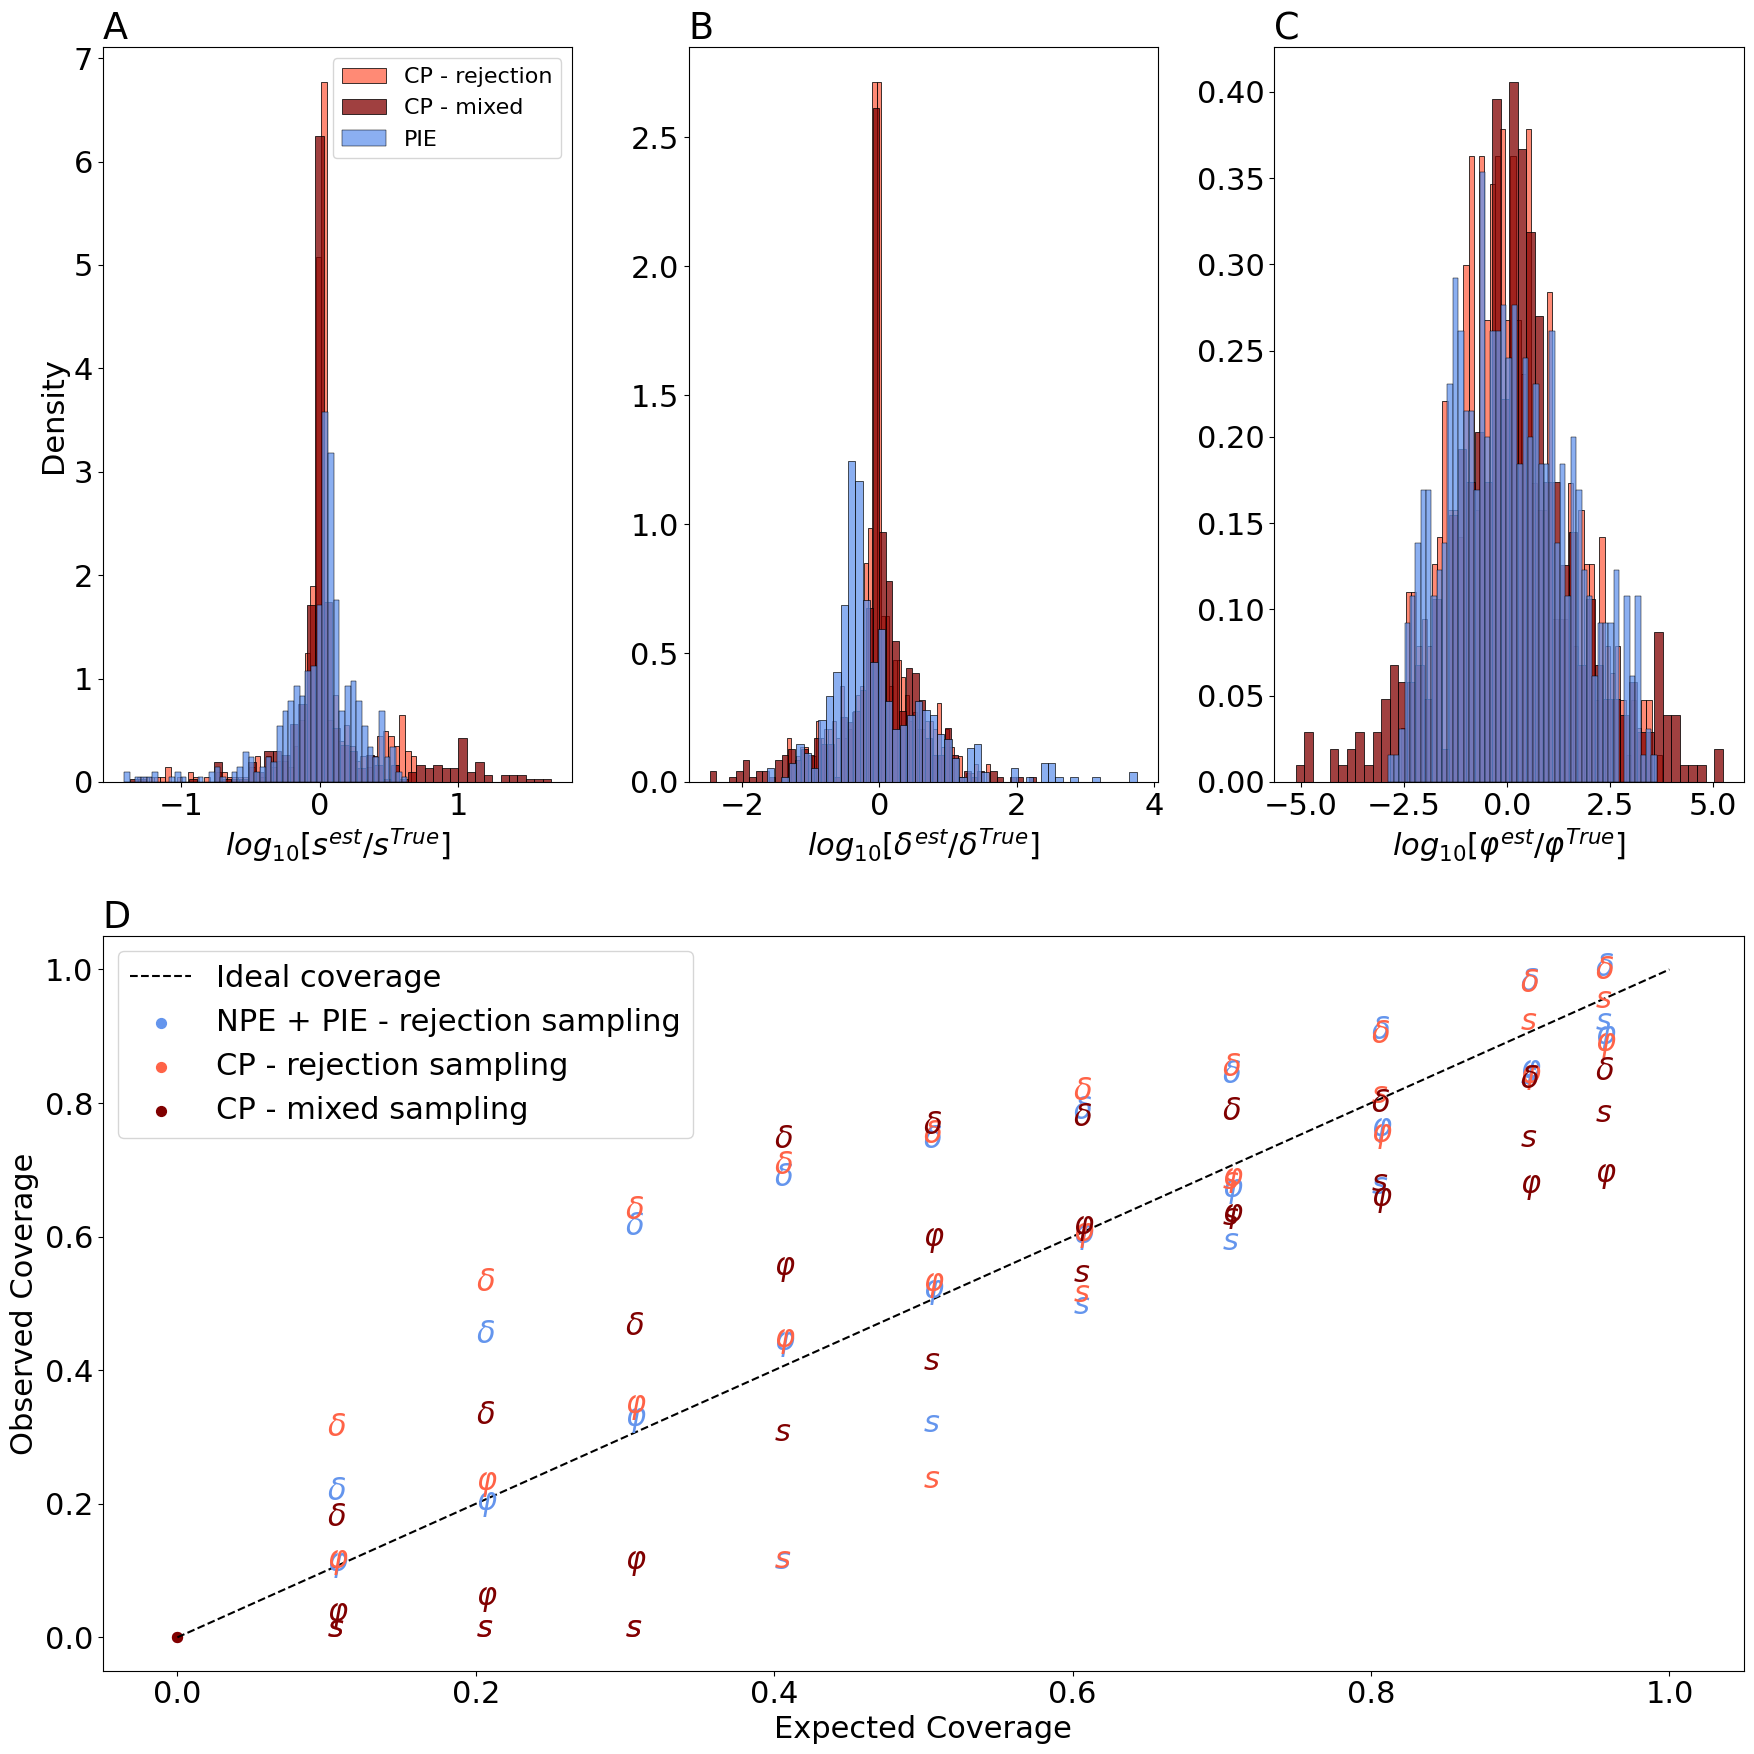

In [13]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE - rejection sampling',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='CP - rejection sampling',color='tomato')
plot_covs_old(ax=ax['D'], covs=covs_cp_m,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='CP - rejection')

cp_m_acc = 'tests/accus_WF_m.csv'
plot_accuracy(cp_m_acc, axx, color='maroon', hatch='', label='CP - mixed')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='PIE')

ax['A'].legend(loc='upper right', fontsize=16)
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

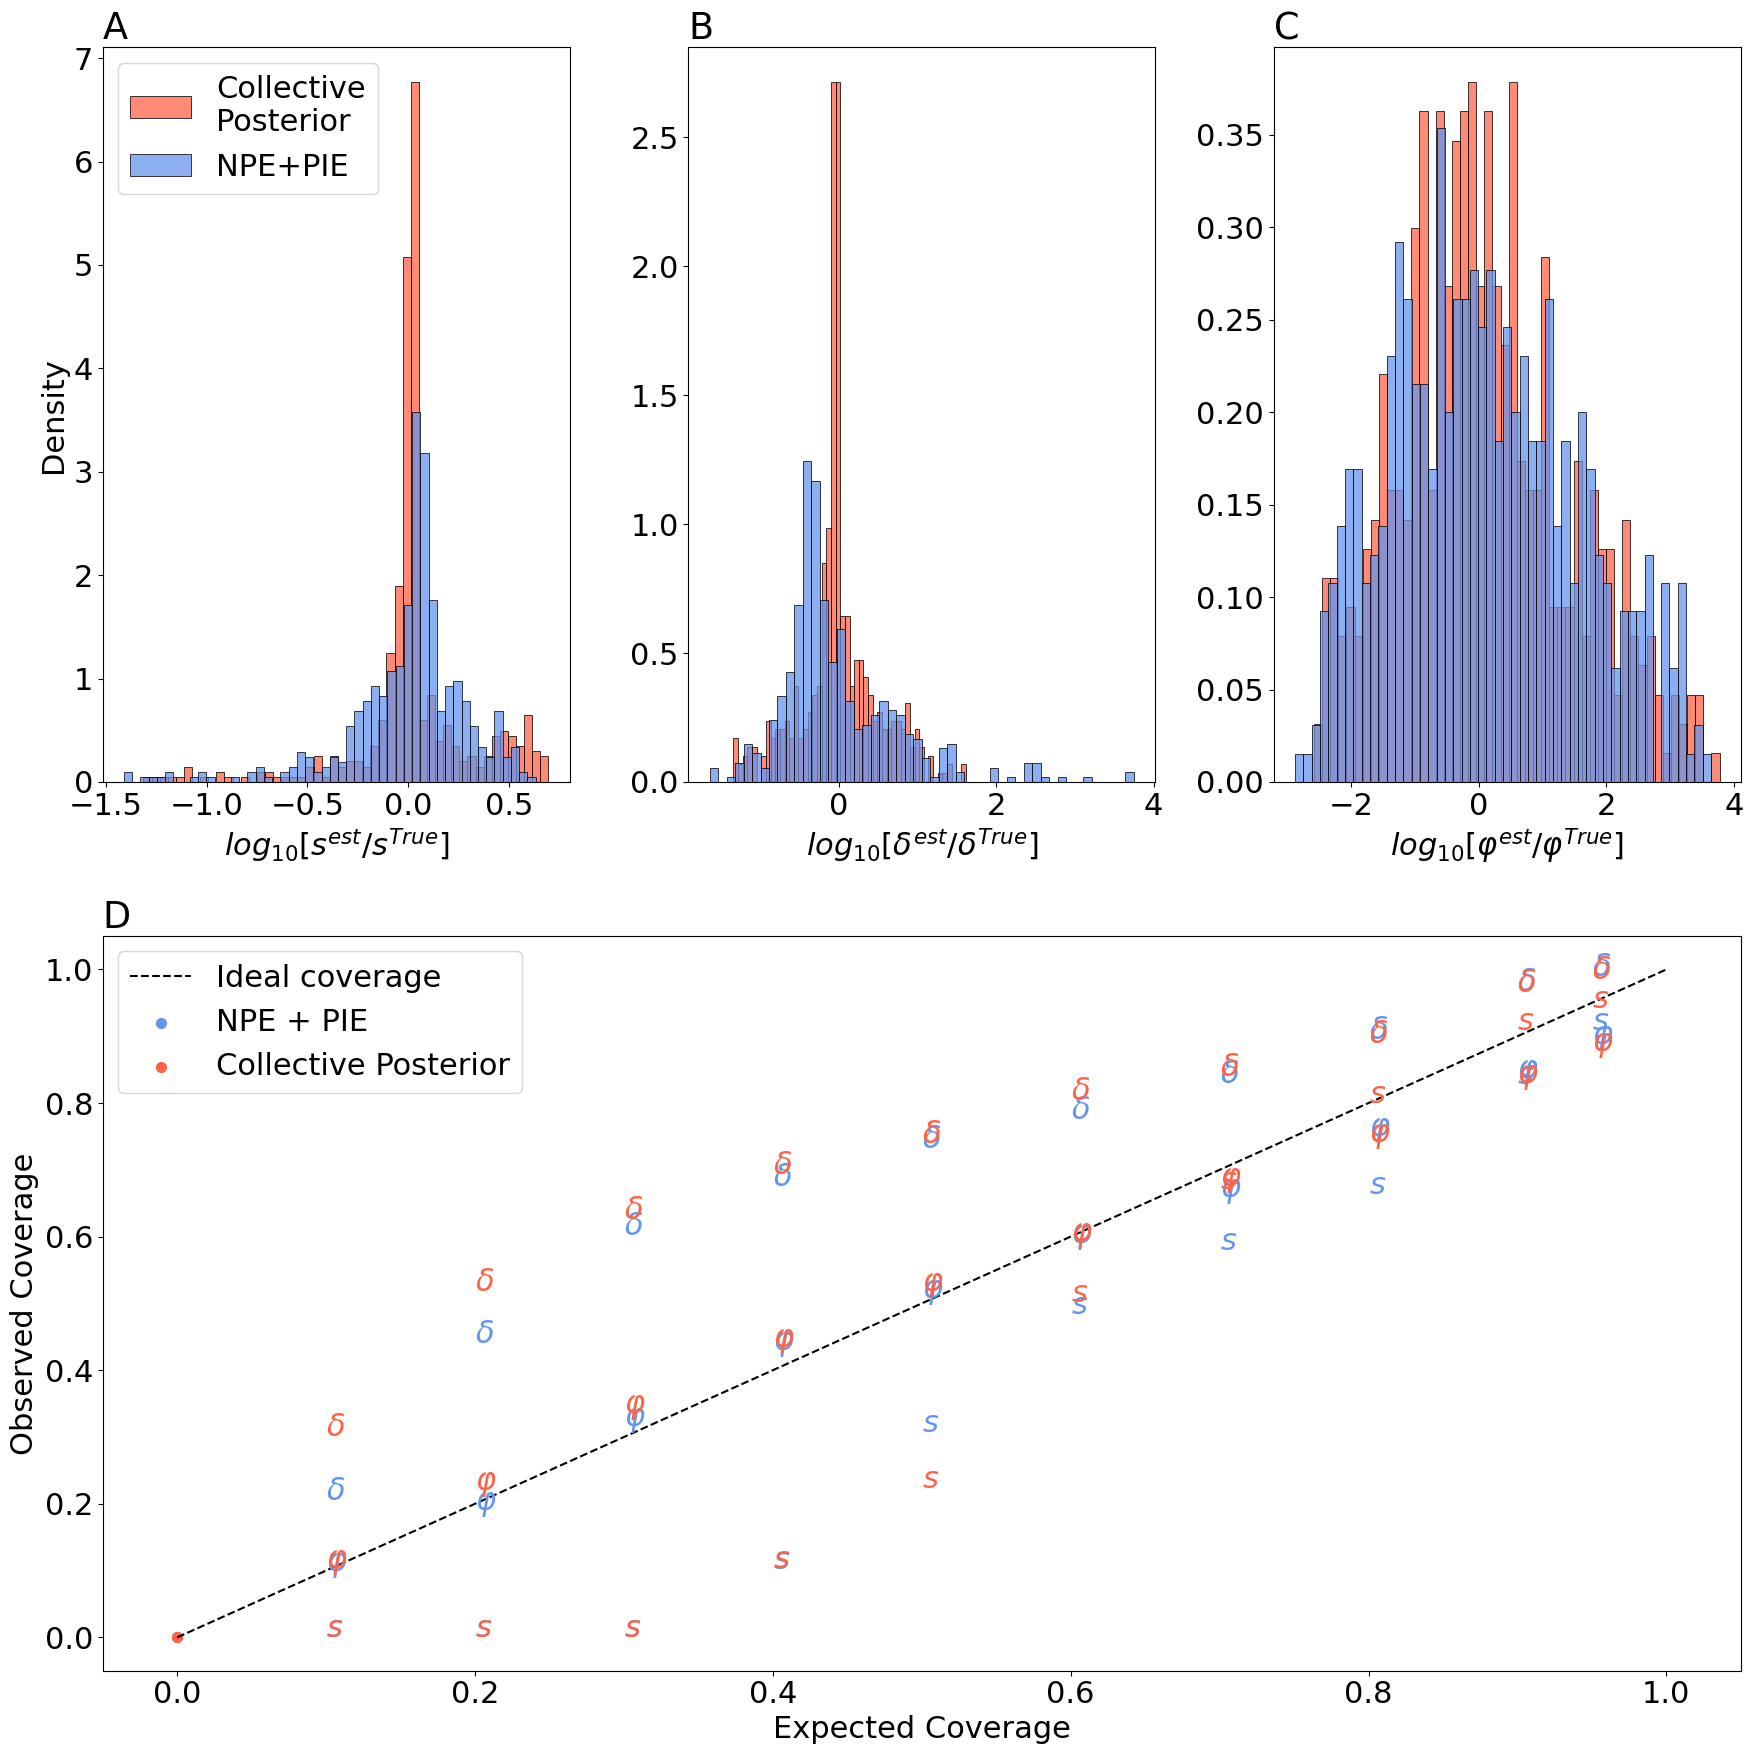

In [15]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='Collective Posterior',color='tomato')


n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['A'].legend()
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



In [29]:
thetas = pd.read_csv('tests/test_thetas.csv', index_col=0)
thetas = torch.from_numpy(np.array(thetas))

cpa = pd.read_csv(cp_acc, index_col=0)
cpa = torch.from_numpy(np.array(cpa))
print(cpa.median(0))
iida = pd.read_csv(iid_acc, index_col=0)
iida = torch.from_numpy(np.array(iida))
print(iida.median(0))

torch.return_types.median(
values=tensor([ 0.0144, -0.0354, -0.0550], dtype=torch.float64),
indices=tensor([119,  11,  95]))
torch.return_types.median(
values=tensor([ 0.0492, -0.2277, -0.0086], dtype=torch.float64),
indices=tensor([ 27,  49, 332]))
